# Desafio Técnico Pin People

Este documento descreve a resolução do desafio técnico proposto pela Pin People, disponível em https://github.com/pin-people/tech_playground.  O foco principal deste trabalho é a resolução das tasks listadas logos abaixo. As soluções propostas para cada tarefa serão detalhadas nas seções subsequentes.


**Task 1: Create a Basic Database**

**Task 5: Exploratory Data Analysis**

**Task 10: Sentiment Analysis**

**Task 12: Creative Exploration**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings("ignore")

import psycopg2
from psycopg2 import pool
import logging
import datetime
from sqlalchemy import create_engine, text

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import spacy
from textblob import TextBlob
import random

In [2]:
data = pd.read_csv('data/data.csv', delimiter=';')
pd.set_option('display.max_columns', None)
data.head()

,nome,email,email_corporativo,area,cargo,funcao,localidade,tempo_de_empresa,genero,geracao,n0_empresa,n1_diretoria,n2_gerencia,n3_coordenacao,n4_area,Data da Resposta,Interesse no Cargo,Comentários - Interesse no Cargo,Contribuição,Comentários - Contribuição,Aprendizado e Desenvolvimento,Comentários - Aprendizado e Desenvolvimento,Feedback,Comentários - Feedback,Interação com Gestor,Comentários - Interação com Gestor,Clareza sobre Possibilidades de Carreira,Comentários - Clareza sobre Possibilidades de Carreira,Expectativa de Permanência,Comentários - Expectativa de Permanência,eNPS,[Aberta] eNPS
0,Demo 001,demo001@pinpeople.com.br,demo001@pinpeople.com.br,administrativo,estagiário,profissional,brasília,entre 1 e 2 anos,masculino,geração z,empresa,diretoria a,gerência a1,coordenação a11,área a112,20/01/2022,7,-,1,-,1,-,6,-,6,-,6,-,2,-,5,A empresa tem um excelente ambiente de trabalh...
1,Demo 002,demo002@pinpeople.com.br,demo002@pinpeople.com.br,comercial,estagiário,profissional,recife,entre 1 e 2 anos,outro,geração z,empresa,diretoria a,gerência a1,coordenação a11,área a111,20/01/2022,1,-,6,Gostaria de liderar iniciativas que agreguem v...,5,-,3,-,6,Meu gestor é acessível e apoia minha carreira.,2,-,6,-,8,Sinto falta de mais oportunidades de crescimen...
2,Demo 003,demo003@pinpeople.com.br,demo003@pinpeople.com.br,financeiro,analista,profissional,brasília,menos de 1 ano,masculino,geração z,empresa,diretoria a,gerência a1,coordenação a11,área a111,20/01/2022,6,-,6,-,7,-,7,A comunicação sobre desempenho é clara.,5,-,2,-,7,Pretendo continuar na empresa por muitos anos.,9,"Os benefícios oferecidos são bons, mas poderia..."
3,Demo 004,demo004@pinpeople.com.br,demo004@pinpeople.com.br,recursos humanos,analista,profissional,recife,entre 1 e 2 anos,feminino,geração z,empresa,diretoria a,gerência a1,coordenação a11,área a112,20/01/2022,5,-,7,-,6,-,5,-,5,-,5,-,1,-,8,A comunicação interna pode ser melhorada para ...
4,Demo 005,demo005@pinpeople.com.br,demo005@pinpeople.com.br,tecnologia,analista,profissional,brasília,entre 2 e 5 anos,outro,geração z,empresa,diretoria a,gerência a1,coordenação a11,área a111,20/01/2022,4,-,5,Sinto que posso contribuir ainda mais com recu...,6,-,5,-,7,-,7,-,1,-,1,Estou satisfeito com a cultura da empresa e co...


## Create a Basic Database

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 32 columns):
 #   Column                                                  Non-Null Count  Dtype 
---  ------                                                  --------------  ----- 
 0   nome                                                    500 non-null    object
 1   email                                                   500 non-null    object
 2   email_corporativo                                       500 non-null    object
 3   area                                                    500 non-null    object
 4   cargo                                                   500 non-null    object
 5   funcao                                                  500 non-null    object
 6   localidade                                              500 non-null    object
 7   tempo_de_empresa                                        500 non-null    object
 8   genero                                            

- Com os tipos das colunas descritas, podemos criar a tabela. O PostgreSQL foi escolhido como banco de dados para o teste.

In [4]:
import psycopg2 # Poderia utilizar também o SQL Alchemy, que tem melhor performance dependendo da base de dados.


logging.basicConfig(filename='import_data.log', level=logging.ERROR,
                    format='%(asctime)s - %(levelname)s - %(message)s')

db_credentials = {
    """
    Credenciais para acessar o banco, como database, user, password e porta.
    Deixando comentado pela proposta do teste.
    """
}

#db_pool = pool.SimpleConnectionPool(1, 20, **db_credentials)

create_table_query = """
CREATE TABLE IF NOT EXISTS data (
    id SERIAL PRIMARY KEY,
    "Nome da Matriz" TEXT,
    "UF da Matriz" TEXT,
    "Nome da Filial" TEXT,
    "UF da Filial" TEXT,
    "Código CNAE Fiscal Principal da Matriz" TEXT,
    "Descrição CNAE Fiscal Principal da Matriz" TEXT,
    "Código CNAE Fiscal Principal da Filial" TEXT,
    "Descrição CNAE Fiscal Principal da Filial" TEXT,
    "Situação Cadastral da Matriz" TEXT,
    "Situação Cadastral da Filial" TEXT,
    "Data de Abertura da Matriz" DATE,
    "Data de Abertura da Filial" DATE,
    "Porte da Empresa - Matriz" TEXT,
    "Porte da Empresa - Filial" TEXT,
    "Quantidade de Funcionários - Matriz" INTEGER,
    "Quantidade de Funcionários - Filial" INTEGER,
    "Município da Matriz" TEXT,
    "Município da Filial" TEXT,
    "DDD Principal Matriz" TEXT,
    "DDD Principal Filial" TEXT,
    "Logradouro da Matriz" TEXT,
    "Logradouro da Filial" TEXT,
    "Número do Logradouro - Matriz" TEXT,
    "Número do Logradouro - Filial" TEXT,
    "Complemento do Logradouro da Matriz" TEXT,
    "Complemento do Logradouro da Filial" TEXT,
    "Bairro da Matriz" TEXT,
    "Bairro da Filial" TEXT,
    "CEP da Matriz" TEXT,
    "CEP da Filial" TEXT,
    "DDD do Fax Matriz" TEXT,
    "DDD do Fax Filial" TEXT,
    "Natureza Jurídica - Matriz" TEXT,
    "Natureza Jurídica - Filial" TEXT,
    "Tipo de Logradouro da Matriz" TEXT,
    "Tipo de Logradouro da Filial" TEXT
);
"""

def create_table():
    try:
        conn = psycopg2.connect(**db_credentials)
        cursor = conn.cursor()
        cursor.execute(create_table_query)
        conn.commit()
    except Exception as e:
        logging.error(f"Erro ao criar a tabela: {e}")
    finally:
        if conn:
            cursor.close()
            conn.close()

def create_indexes():
    conn = db_pool.getconn()
    try:
        cursor = conn.cursor()
        index_queries = [
            "CREATE INDEX IF NOT EXISTS idx_nome_matriz ON data (\"Nome da Matriz\")",
            "CREATE INDEX IF NOT EXISTS idx_uf_matriz ON data (\"UF da Matriz\")",
            "CREATE INDEX IF NOT EXISTS idx_cnae_matriz ON data (\"Código CNAE Fiscal Principal da Matriz\")"
        ]
        for query in index_queries:
            cursor.execute(query)
        conn.commit()
        logging.info("Índices criados com sucesso.")
    except Exception as e:
        logging.error(f"Erro ao criar índices: {e}")
    finally:
        db_pool.putconn(conn)

def validate_data(row):
    try:
        if row["Data de Abertura da Matriz"]:
            datetime.strptime(row["Data de Abertura da Matriz"], "%Y-%m-%d")
        if row["Data de Abertura da Filial"]:
            datetime.strptime(row["Data de Abertura da Filial"], "%Y-%m-%d")
        return True
    except Exception as e:
        logging.warning(f"Erro de validação na linha {row}: {e}")
        return False

def import_csv_to_db(data):
    try:
        conn = psycopg2.connect(**db_credentials)
        cursor = conn.cursor()

        insert_query = """
        INSERT INTO data (
            "Nome da Matriz", "UF da Matriz", "Nome da Filial", "UF da Filial",
            "Código CNAE Fiscal Principal da Matriz", "Descrição CNAE Fiscal Principal da Matriz",
            "Código CNAE Fiscal Principal da Filial", "Descrição CNAE Fiscal Principal da Filial",
            "Situação Cadastral da Matriz", "Situação Cadastral da Filial",
            "Data de Abertura da Matriz", "Data de Abertura da Filial",
            "Porte da Empresa - Matriz", "Porte da Empresa - Filial",
            "Quantidade de Funcionários - Matriz", "Quantidade de Funcionários - Filial",
            "Município da Matriz", "Município da Filial", "DDD Principal Matriz",
            "DDD Principal Filial", "Logradouro da Matriz", "Logradouro da Filial",
            "Número do Logradouro - Matriz", "Número do Logradouro - Filial",
            "Complemento do Logradouro da Matriz", "Complemento do Logradouro da Filial",
            "Bairro da Matriz", "Bairro da Filial", "CEP da Matriz", "CEP da Filial",
            "DDD do Fax Matriz", "DDD do Fax Filial", "Natureza Jurídica - Matriz",
            "Natureza Jurídica - Filial", "Tipo de Logradouro da Matriz", "Tipo de Logradouro da Filial"
        ) VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s)
        """
        valid_data = [tuple(row) for _, row in data.iterrows() if validate_data(row)]
        values = [tuple(row) for _, row in data.itertuples()]
        cursor.executemany(insert_query, values)
        conn.commit()

    except Exception as e:
        logging.error(f"Erro ao importar dados: {e}")
    finally:
        if conn:
            cursor.close()
            conn.close()

#create_table()
#import_csv_to_db(data)

- O exemplo abaixo é utilizando SQL Alchemy

In [5]:
logging.basicConfig(filename='import_data.log', level=logging.ERROR,
                    format='%(asctime)s - %(levelname)s - %(message)s')

db_credentials = {
    'user': '',
    'password': '',
    'host': '',
    'port': '',
    'database': 'postgres'
}

db_connection_str = f"postgresql://{db_credentials['user']}:{db_credentials['password']}@{db_credentials['host']}:{db_credentials['port']}/{db_credentials['database']}"

#engine = create_engine(db_connection_str)

create_table_query = """
    A mesma tipagem do primeiro exemplo.
);
"""

def create_table():
    try:
        with engine.connect() as conn:
            conn.execute(text(create_table_query))
    except Exception as e:
        logging.error(f"Erro ao criar a tabela: {e}")


def import_csv_to_db(data):
    try:
        data.to_sql('data', engine, if_exists='append', index=False)
    except Exception as e:
        logging.error(f"Erro ao importar dados: {e}")


#create_table()
# import_csv_to_db(data)

O objetivo do script é automatizar a importação de dados de um CSV para o PostgreSQL, validando as informações e garantindo a integridade dos dados. Ele foi otimizado para performance com índices e pool de conexões, além de registrar erros para facilitar a manutenção.

***Próximos Passos:***
Aprimorar a Validação de Dados: Implementar validações adicionais para outros campos, como tipos de dados e formatos específicos.

Implementar o Tratamento de Dados Inválidos: Definir estratégias para lidar com dados inválidos, como ignorar linhas com erros ou aplicar correções.

## Exploratory Data Analysis


In [6]:
data.describe()

,Interesse no Cargo,Contribuição,Aprendizado e Desenvolvimento,Feedback,Interação com Gestor,Clareza sobre Possibilidades de Carreira,Expectativa de Permanência,eNPS
count,500.00000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,5.72400,5.648000,5.432000,5.390000,4.918000,4.202000,3.906000,7.544000
std,1.62268,1.670232,1.549897,1.602197,1.685514,1.850417,1.989241,2.486046
min,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,6.00000,6.000000,5.000000,5.000000,4.000000,3.000000,2.000000,6.000000
50%,6.00000,6.000000,6.000000,6.000000,5.000000,4.000000,4.000000,8.000000
75%,7.00000,7.000000,7.000000,7.000000,6.000000,6.000000,6.000000,9.000000
max,7.00000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,10.000000


In [7]:
missing_values = data.isnull().sum()
missing_values

nome                                                      0
email                                                     0
email_corporativo                                         0
area                                                      0
cargo                                                     0
funcao                                                    0
localidade                                                0
tempo_de_empresa                                          0
genero                                                    0
geracao                                                   0
n0_empresa                                                0
n1_diretoria                                              0
n2_gerencia                                               0
n3_coordenacao                                            0
n4_area                                                   0
Data da Resposta                                          0
Interesse no Cargo                      

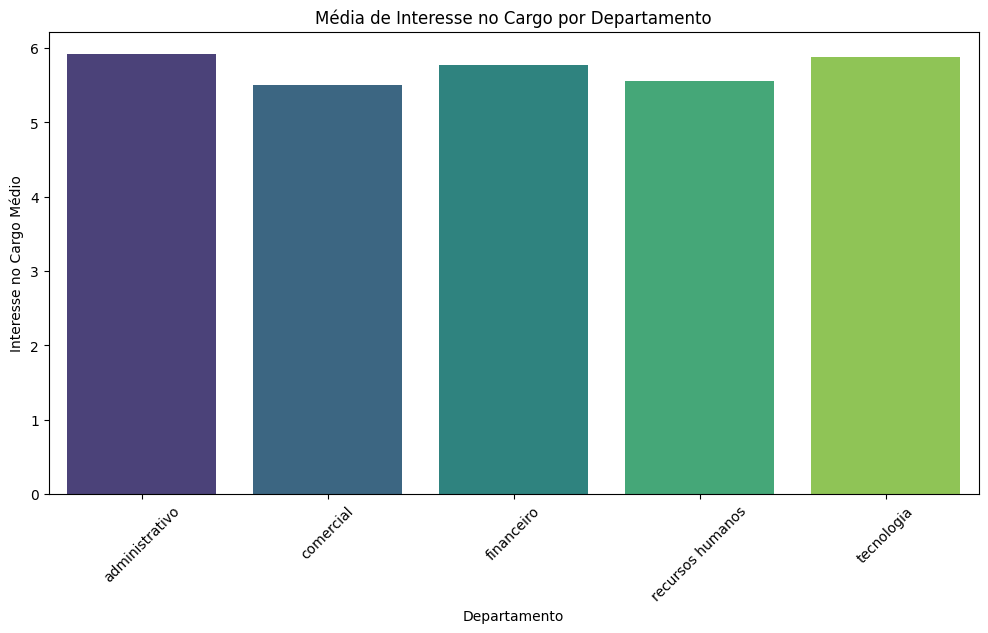

In [8]:
media_interesse_cargo_por_area = data.groupby('area')['Interesse no Cargo'].mean()

plt.figure(figsize=(12, 6))
sns.barplot(x=media_interesse_cargo_por_area.index, y=media_interesse_cargo_por_area.values, palette='viridis')
plt.title('Média de Interesse no Cargo por Departamento')
plt.xlabel('Departamento')
plt.ylabel('Interesse no Cargo Médio')
plt.xticks(rotation=45)
plt.show()

- O departamento administrativo apresenta o maior nível de interesse no cargo.
Uma possível interpretação é que o departamento administrativo pode ter maior clareza sobre as funções e responsabilidades do cargo, ou maior identificação com as tarefas.

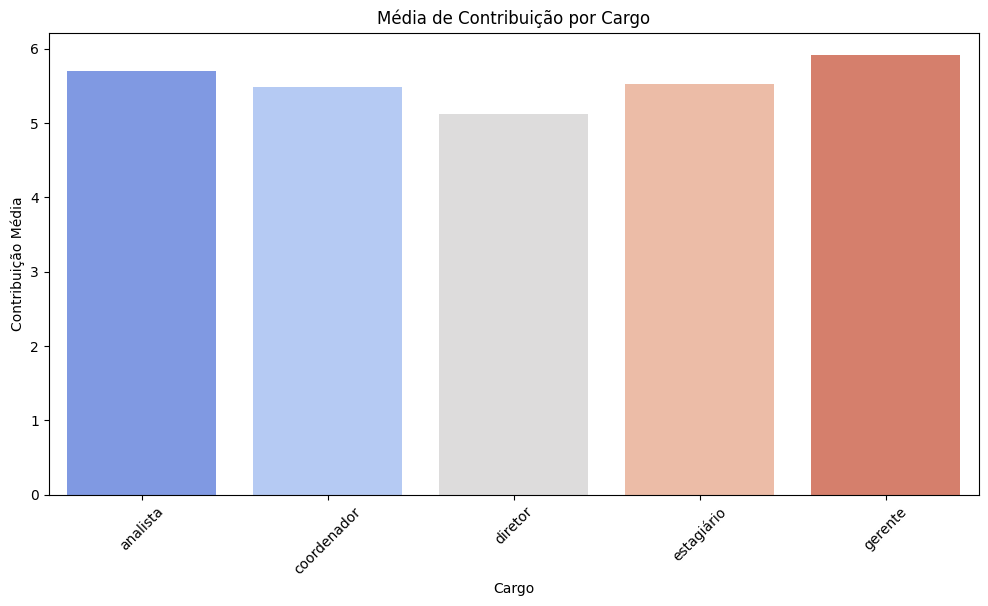

In [9]:
media_contribuicao_por_cargo = data.groupby('cargo')['Contribuição'].mean()

plt.figure(figsize=(12, 6))
sns.barplot(x=media_contribuicao_por_cargo.index, y=media_contribuicao_por_cargo.values, palette='coolwarm')
plt.title('Média de Contribuição por Cargo')
plt.xlabel('Cargo')
plt.ylabel('Contribuição Média')
plt.xticks(rotation=45)
plt.show()


Observações:
- Gerentes e diretores apresentam as maiores médias de contribuição.
- Analistas e coordenadores têm médias de contribuição semelhantes entre si, e menores do que gerentes e diretores.
- Estagiários demonstram a menor média de contribuição.

Possíveis interpretações:
- Os cargos de liderança possuem maior impacto na empresa, justificando a maior contribuição.
- Analistas e coordenadores podem ter responsabilidades e influência mais limitadas, resultando em menor contribuição.
- Estagiários, por estarem em fase de aprendizagem, naturalmente contribuem menos no momento.

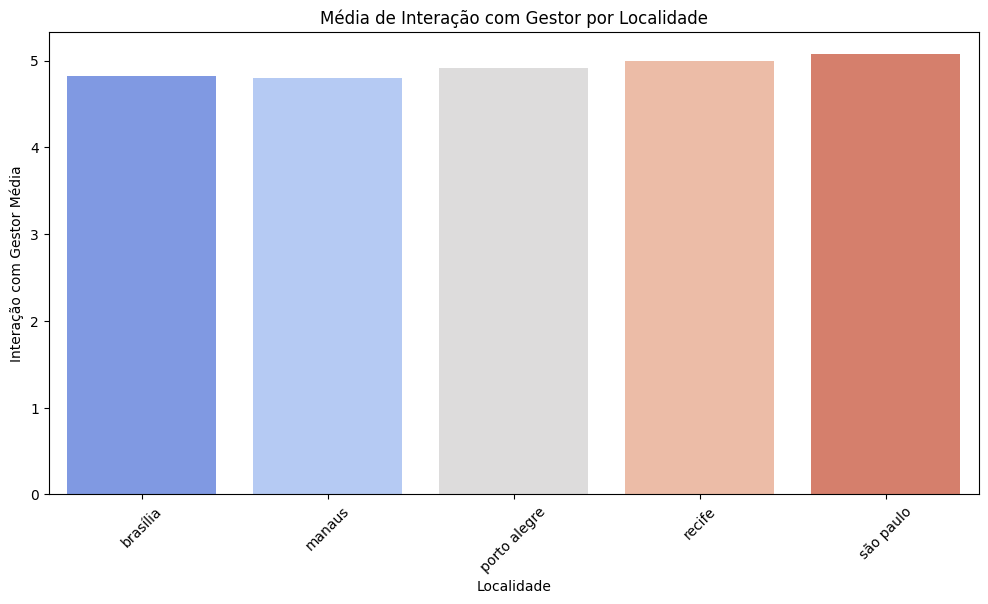

In [10]:
media_interacao_por_localidade = data.groupby('localidade')['Interação com Gestor'].mean()

plt.figure(figsize=(12, 6))
sns.barplot(x=media_interacao_por_localidade.index, y=media_interacao_por_localidade.values, palette='coolwarm')
plt.title('Média de Interação com Gestor por Localidade')
plt.xlabel('Localidade')
plt.ylabel('Interação com Gestor Média')
plt.xticks(rotation=45)
plt.show()


Observações:
- Brasília e Manaus apresentam as maiores médias de interação com o gestor.
- Porto Alegre possui a menor média.
- Recife e São Paulo demonstram médias intermediárias, próximas uma da outra.

Possíveis interpretações:
- Em Brasília e Manaus, a cultura organizacional pode favorecer uma maior proximidade entre gestores e colaboradores, ou os gestores podem ser mais acessíveis nestas localidades.

- Em Porto Alegre, a estrutura organizacional ou o estilo de gestão podem resultar em menor interação entre gestores e colaboradores.

- Recife e São Paulo podem ter modelos de interação mais equilibrados ou similares.

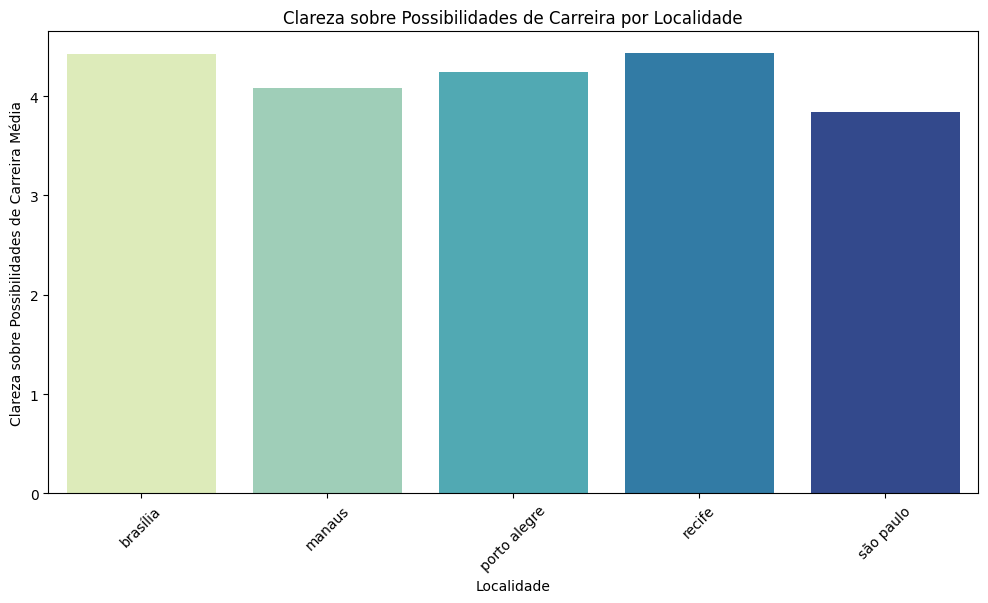

In [11]:
media_clareza_por_localidade = data.groupby('localidade')['Clareza sobre Possibilidades de Carreira'].mean()

plt.figure(figsize=(12, 6))
sns.barplot(x=media_clareza_por_localidade.index, y=media_clareza_por_localidade.values, palette='YlGnBu')
plt.title('Clareza sobre Possibilidades de Carreira por Localidade')
plt.xlabel('Localidade')
plt.ylabel('Clareza sobre Possibilidades de Carreira Média')
plt.xticks(rotation=45)
plt.show()


Observações:

- São Paulo apresenta a maior clareza sobre as possibilidades de carreira.
- Brasília e Manaus demonstram os menores níveis de clareza.
- Porto Alegre e Recife têm níveis de clareza intermediários, próximos um do outro e mais próximos de São Paulo.

Possíveis interpretações:

- Em São Paulo, a empresa pode ter processos mais estruturados de gestão de carreira, com planos de desenvolvimento individual e comunicação transparente sobre as oportunidades de crescimento.
- Brasília e Manaus podem ter lacunas na comunicação e no desenvolvimento de planos de carreira, gerando incerteza sobre as possibilidades de progressão profissional.
- Porto Alegre e Recife podem ter modelos intermediários de gestão de carreira, com espaço para melhorias na comunicação e no desenvolvimento de planos de carreira.



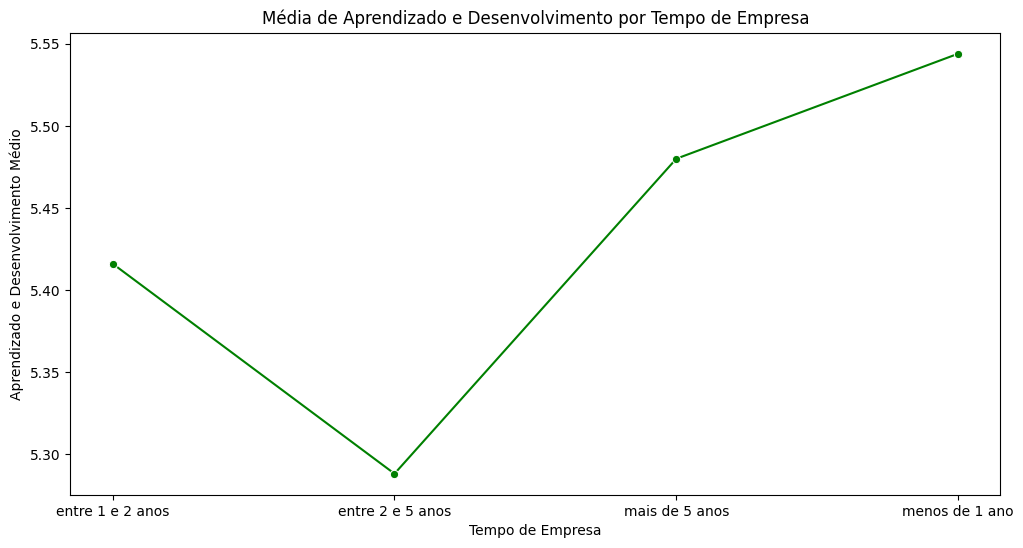

In [12]:
media_aprendizado_por_tempo = data.groupby('tempo_de_empresa')['Aprendizado e Desenvolvimento'].mean()

plt.figure(figsize=(12, 6))
sns.lineplot(x=media_aprendizado_por_tempo.index, y=media_aprendizado_por_tempo.values, marker='o', color='green')
plt.title('Média de Aprendizado e Desenvolvimento por Tempo de Empresa')
plt.xlabel('Tempo de Empresa')
plt.ylabel('Aprendizado e Desenvolvimento Médio')
plt.show()


Observações:
- A média de aprendizado e desenvolvimento aumenta com o tempo de empresa até o período "mais de 5 anos", onde atinge seu pico.
- Colaboradores com "menos de 1 ano" de empresa apresentam uma média levemente superior aos que estão na faixa "entre 1 e 2 anos".
- O menor valor de aprendizado e desenvolvimento médio ocorre no período "entre 2 e 5 anos".

Possíveis Interpretações:
- Os colaboradores com mais tempo de empresa podem ter mais acesso a oportunidades de aprendizado e desenvolvimento, como treinamentos, mentorias e projetos desafiadores.
- A curva de aprendizado pode ser mais acentuada no início da carreira, com um declínio após o período inicial ("entre 2 e 5 anos") e uma retomada posterior.
- Colaboradores recém-contratados ("menos de 1 ano") podem se beneficiar de programas de integração e incentivos à capacitação.
Pode haver fatores específicos que influenciam o aprendizado e desenvolvimento em cada fase da carreira na empresa.

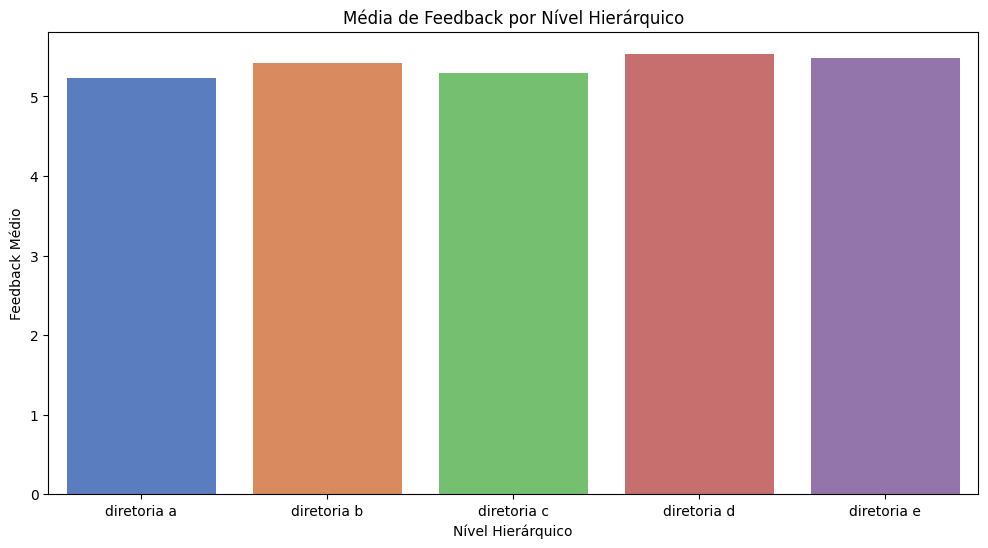

In [13]:
media_feedback_por_nivel = data.groupby('n1_diretoria')['Feedback'].mean()

plt.figure(figsize=(12, 6))
sns.barplot(x=media_feedback_por_nivel.index, y=media_feedback_por_nivel.values, palette='muted')
plt.title('Média de Feedback por Nível Hierárquico')
plt.xlabel('Nível Hierárquico')
plt.ylabel('Feedback Médio')
plt.show()


Observações:
- As diretorias "a", "c" e "e" apresentam as maiores médias de feedback, com valores muito próximos.
- As diretorias "b" e "d" têm médias de feedback ligeiramente inferiores, também com valores similares entre si.
- No geral, as médias de feedback entre as diretorias são bastante próximas, com variações pequenas.

Possíveis interpretações:
- Cultura de feedback na empresa pode ser relativamente homogênea entre os diferentes níveis hierárquicos, com pequenas variações entre as diretorias.
- As diretorias "a", "c" e "e" podem ter processos de feedback mais estruturados ou uma maior ênfase na importância do feedback.
- As diretorias "b" e "d" podem ter oportunidades de melhoria em seus processos de feedback, buscando incentivar a prática e garantir que seja construtivo e eficaz.

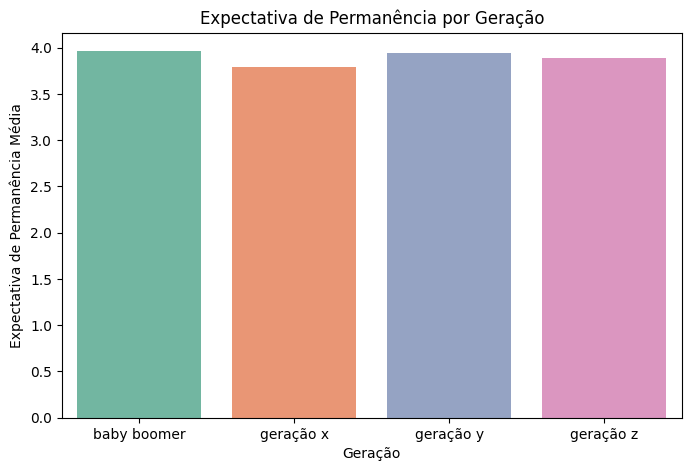

In [14]:
media_expectativa_por_geracao = data.groupby('geracao')['Expectativa de Permanência'].mean()

plt.figure(figsize=(8, 5))
sns.barplot(x=media_expectativa_por_geracao.index, y=media_expectativa_por_geracao.values, palette='Set2')
plt.title('Expectativa de Permanência por Geração')
plt.xlabel('Geração')
plt.ylabel('Expectativa de Permanência Média')
plt.show()


Observações:

- As gerações Baby Boomer, X e Y apresentam expectativas de permanência muito similares, com médias próximas a 4.
- A geração Z demonstra uma expectativa de permanência levemente inferior, próxima a 3,5.

Possíveis interpretações:

- As gerações mais antigas podem valorizar mais a estabilidade e o crescimento a longo prazo dentro da empresa.
- A geração Z pode ter uma visão mais dinâmica do mercado de trabalho, buscando novas experiências e oportunidades com maior frequência.
- Fatores geracionais, como valores, expectativas e necessidades, podem influenciar a perspectiva de permanência na empresa.



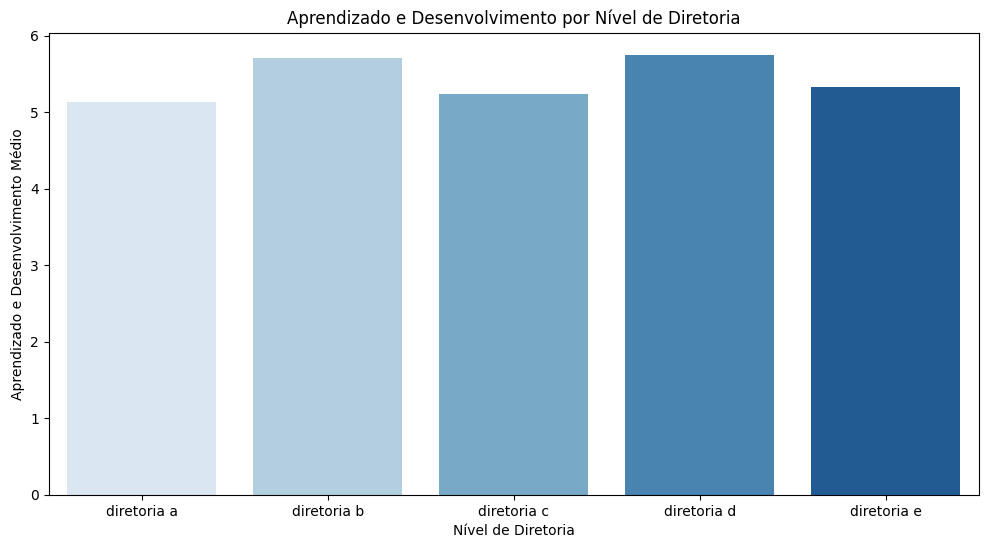

In [15]:
media_aprendizado_por_nivel = data.groupby('n1_diretoria')['Aprendizado e Desenvolvimento'].mean()

plt.figure(figsize=(12, 6))
sns.barplot(x=media_aprendizado_por_nivel.index, y=media_aprendizado_por_nivel.values, palette='Blues')
plt.title('Aprendizado e Desenvolvimento por Nível de Diretoria')
plt.xlabel('Nível de Diretoria')
plt.ylabel('Aprendizado e Desenvolvimento Médio')
plt.show()


Observações:

- As diretorias "a" e "c" apresentam as menores médias de aprendizado e desenvolvimento.
- As diretorias "b", "d" e "e" mostram médias superiores, com valores próximos entre si.
- A diretoria "d" se destaca com a maior média.

Possíveis interpretações:

- As diretorias "b", "d" e "e" podem oferecer mais oportunidades de aprendizado e desenvolvimento aos seus colaboradores, como treinamentos, workshops e programas de mentoria.
- As diretorias "a" e "c" podem ter lacunas em seus programas de aprendizado e desenvolvimento, necessitando de investimentos e aprimoramento.
- A diretoria "d" pode ser um exemplo de boas práticas em aprendizado e desenvolvimento, com iniciativas que impactam positivamente seus colaboradores.

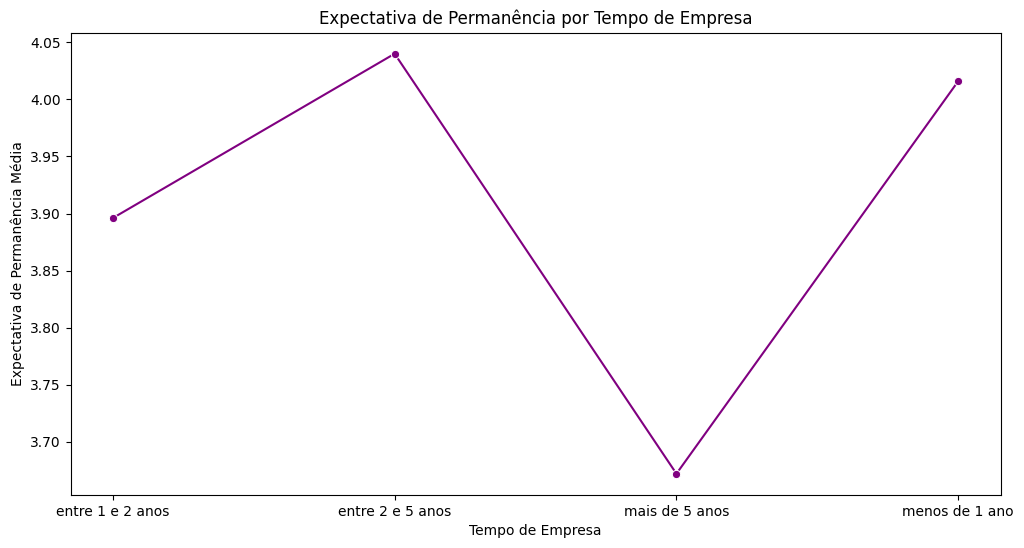

In [16]:
media_expectativa_por_tempo = data.groupby('tempo_de_empresa')['Expectativa de Permanência'].mean()

plt.figure(figsize=(12, 6))
sns.lineplot(x=media_expectativa_por_tempo.index, y=media_expectativa_por_tempo.values, marker='o', color='purple')
plt.title('Expectativa de Permanência por Tempo de Empresa')
plt.xlabel('Tempo de Empresa')
plt.ylabel('Expectativa de Permanência Média')
plt.show()


Observações:

- A expectativa de permanência aumenta com o tempo de empresa, exceto para a categoria "entre 2 e 5 anos", que apresenta a menor média.
- Colaboradores com "menos de 1 ano" e "mais de 5 anos" demonstram as maiores expectativas de permanência, com valores próximos entre si.
- A expectativa de permanência cai entre aqueles com "entre 1 e 2 anos" e "entre 2 e 5 anos" de empresa.

Possíveis interpretações:

- Colaboradores recém-contratados podem ter alta expectativa de permanência devido ao entusiasmo inicial, novas oportunidades e desejo de construir carreira na empresa.
- A queda na expectativa de permanência entre "1 e 2 anos" e "2 e 5 anos" pode indicar um período de adaptação, onde os colaboradores reavaliam suas perspectivas e buscam novas experiências caso não estejam satisfeitos.
- Colaboradores com "mais de 5 anos" podem ter maior identificação com a empresa, estabilidade em suas carreiras e benefícios que os motivam a permanecer.

Observações:

As expectativas de permanência média para "gestor" e "profissional" são praticamente iguais.

Possíveis interpretações:

A empresa pode ter um ambiente de trabalho que promove a satisfação e o desenvolvimento tanto para gestores quanto para profissionais, resultando em expectativas de permanência similares.
Políticas de retenção e benefícios podem ser equivalentes para ambas as funções, não influenciando significativamente na expectativa de permanência.
A cultura da empresa pode valorizar a contribuição de todos os colaboradores, independentemente da função, criando um senso de pertencimento e propósito.

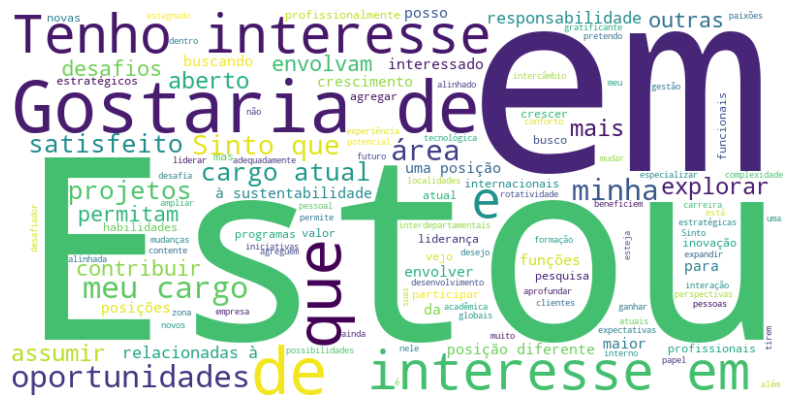

In [17]:
# wordcloud para 'Comentários - Interesse no Cargo'
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(data['Comentários - Interesse no Cargo'].dropna()))
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()


Esta nuvem de palavras apresenta os termos mais frequentes nos comentários sobre interesse no cargo.

A nuvem sugere que os colaboradores têm um engajamento em relação ao cargo e estão ativamente buscando oportunidades de crescimento e desenvolvimento. As palavras-chave indicam que os colaboradores desejam contribuir ativamente, participar de projetos desafiadores e assumir responsabilidades.

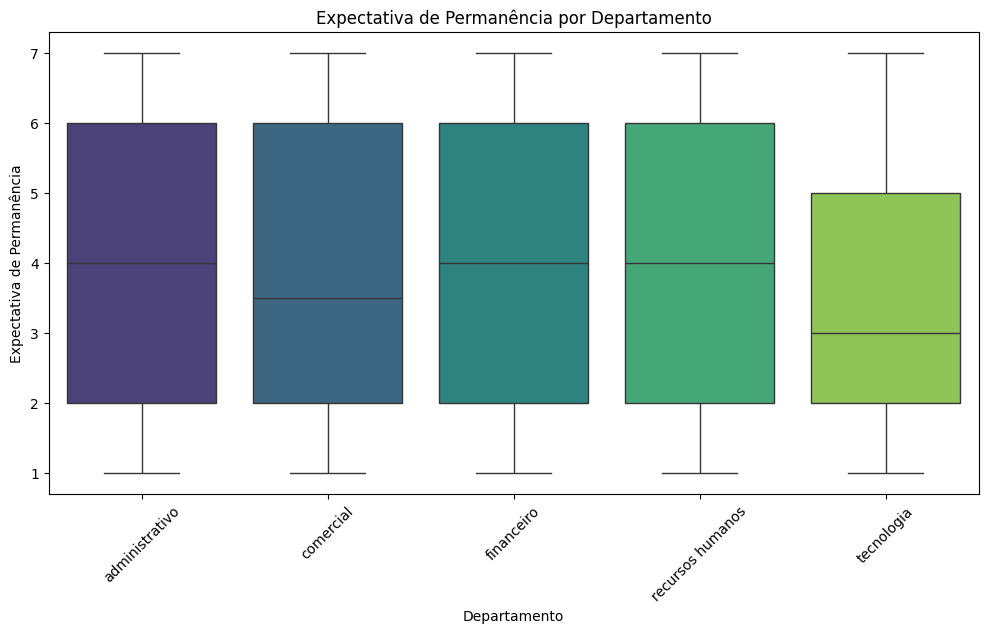

In [18]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='area', y='Expectativa de Permanência', data=data, palette='viridis')
plt.title('Expectativa de Permanência por Departamento')
plt.xlabel('Departamento')
plt.ylabel('Expectativa de Permanência')
plt.xticks(rotation=45)
plt.show()


Observações:

- Administrativo, Comercial e Financeiro: Apresentam expectativas de permanência mais altas e similares, com medianas próximas a 5 e distribuições relativamente concentradas.
- Recursos Humanos: Mostra uma expectativa de permanência levemente inferior, com mediana próxima a 4,5 e uma distribuição um pouco mais dispersa.
- Tecnologia: Possui a menor expectativa de permanência, com mediana em torno de 3 e a distribuição mais dispersa entre os departamentos, com alguns outliers (valores discrepantes) baixos.

Possíveis interpretações:

- Os departamentos Administrativo, Comercial e Financeiro podem oferecer maior estabilidade, oportunidades de crescimento ou ambiente de trabalho mais favorável, resultando em maior expectativa de permanência.
- O departamento de Recursos Humanos pode ter fatores específicos que influenciam a expectativa de permanência, como rotatividade natural da área ou desafios específicos do setor.
- O departamento de Tecnologia pode enfrentar maior concorrência por talentos, rotatividade devido a oportunidades no mercado ou insatisfação com alguns aspectos do trabalho, resultando na menor expectativa de permanência.

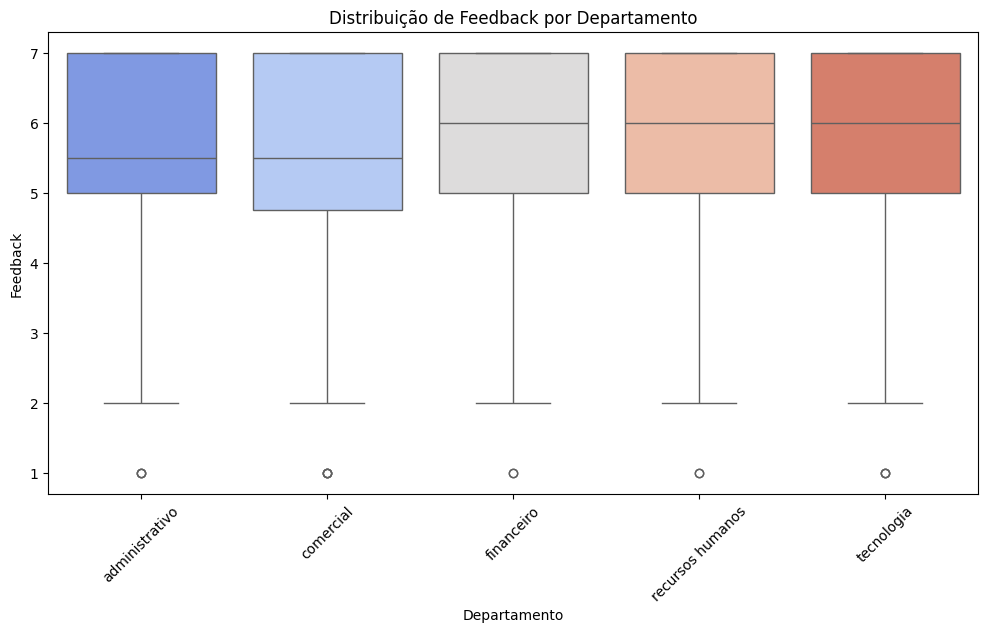

In [19]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='area', y='Feedback', data=data, palette='coolwarm')
plt.title('Distribuição de Feedback por Departamento')
plt.xlabel('Departamento')
plt.ylabel('Feedback')
plt.xticks(rotation=45)
plt.show()


Observações:

- Administrativo: Apresenta a maior mediana de feedback, indicando que, em geral, os colaboradores desse departamento tendem a dar notas mais altas.
- Comercial e Financeiro: Mostram medianas de feedback ligeiramente inferiores ao Administrativo, mas ainda bastante próximas.
Recursos Humanos e Tecnologia: Possuem as menores medianas de feedback, com a - Tecnologia apresentando a menor entre todos os departamentos.
- Variabilidade: A variabilidade do feedback é semelhante entre os departamentos, com exceção de Recursos Humanos, que apresenta uma dispersão um pouco maior.
- Outliers: Existem alguns outliers em todos os departamentos, indicando a presença de feedbacks discrepantes em relação à maioria.

Possíveis interpretações:

- O departamento Administrativo pode ter uma cultura mais forte de feedback positivo ou seus colaboradores podem estar mais satisfeitos com os processos e as relações interpessoais.
- Os departamentos de Recursos Humanos e Tecnologia podem ter oportunidades de melhoria nos processos de feedback, buscando incentivar a participação, garantir a qualidade do feedback e abordar as causas dos feedbacks mais baixos.
- Os outliers podem indicar a necessidade de investigar casos específicos de feedback muito positivo ou muito negativo, buscando entender os fatores que contribuíram para essas avaliações.

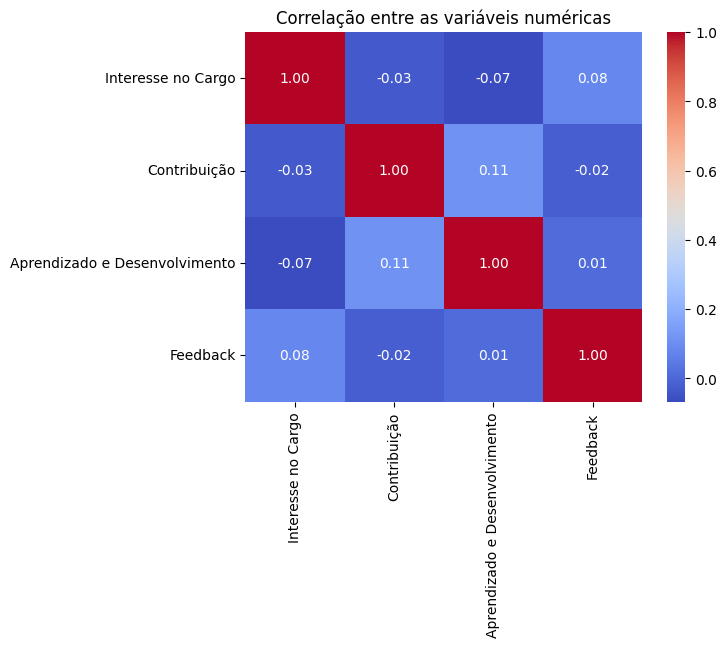

In [20]:
correlacao = data[['Interesse no Cargo', 'Contribuição', 'Aprendizado e Desenvolvimento', 'Feedback']].corr()

sns.heatmap(correlacao, annot=True, cmap='coolwarm', fmt='.2f', cbar=True)
plt.title('Correlação entre as variáveis numéricas')
plt.show()


O mapa de calor sugere que as variáveis numéricas analisadas são relativamente independentes entre si. A exceção é a relação fraca a moderada entre "Contribuição" e "Aprendizado e Desenvolvimento", que pode indicar que colaboradores que contribuem mais tendem a se desenvolver mais, possivelmente por terem mais oportunidades de aprendizado ou por serem mais engajados em seu desenvolvimento profissional.

### Conclusão


Após análise dos gráficos e seus resumos, podemos traçar um panorama geral da situação da empresa em relação aos seguintes aspectos:

Interesse no Cargo:

* O departamento administrativo demonstra maior interesse no cargo, enquanto os demais se mostram relativamente similares. Isso pode indicar a necessidade de melhor comunicação sobre as funções e responsabilidades do cargo nos departamentos com menor interesse.

Contribuição:

* Cargos de liderança (gerentes e diretores) apresentam maior contribuição, o que é esperado. Analistas e coordenadores contribuem de forma similar, enquanto estagiários demonstram a menor contribuição. É importante que a empresa incentive o desenvolvimento e a progressão de carreira para que todos os colaboradores possam aumentar sua contribuição ao longo do tempo.

Feedback:

* Não há diferenças significativas na média de feedback por gênero, o que sugere igualdade nesse quesito. As diretorias "a", "c" e "e" apresentam as maiores médias de feedback, indicando que podem ter processos mais estruturados. As demais diretorias podem se beneficiar de aprimorar seus processos de feedback.

Interação com o Gestor:

* Brasília e Manaus demonstram maior interação com o gestor, enquanto Porto Alegre apresenta a menor. Isso pode refletir diferenças na cultura organizacional ou no estilo de gestão de cada localidade. É importante que a empresa promova uma interação saudável e eficaz entre gestores e colaboradores em todas as localidades.

Aprendizado e Desenvolvimento:

* A média de aprendizado e desenvolvimento aumenta com o tempo de empresa, com exceção da faixa entre 2 e 5 anos, que apresenta a menor média. As diretorias "b", "d" e "e" oferecem mais oportunidades de aprendizado e desenvolvimento. A empresa deve investir em programas de aprendizado e desenvolvimento contínuos para todos os colaboradores, com atenção especial àqueles entre 2 e 5 anos de empresa.

Clareza sobre Possibilidades de Carreira:

* São Paulo apresenta a maior clareza sobre as possibilidades de carreira, enquanto Brasília e Manaus demonstram os menores níveis. A empresa deve melhorar a comunicação e os processos de gestão de carreira em todas as localidades, especialmente em Brasília e Manaus.

Expectativa de Permanência:

* As gerações Baby Boomer, X e Y demonstram expectativas de permanência similares e maiores que a geração Z. A expectativa de permanência aumenta com o tempo de empresa, exceto para a faixa entre 2 e 5 anos.  A empresa deve promover ações para reter talentos de todas as gerações, com foco na geração Z e naqueles entre 2 e 5 anos de empresa.

Correlação entre Variáveis:

* A maior correlação ocorre entre "Contribuição" e "Aprendizado e Desenvolvimento", sugerindo que colaboradores que contribuem mais tendem a se desenvolver mais. As demais correlações são fracas, indicando que as variáveis são relativamente independentes.

Considerações:

* A empresa apresenta alguns pontos fortes, como a igualdade no feedback entre gêneros e a alta expectativa de permanência em algumas faixas de tempo de empresa.
* Há oportunidades de melhoria na comunicação sobre o cargo, nos processos de feedback em algumas diretorias, na interação com o gestor em algumas localidades, no aprendizado e desenvolvimento para colaboradores entre 2 e 5 anos de empresa, na clareza sobre as possibilidades de carreira e na retenção de talentos da geração Z.
* É importante que a empresa aprofunde as análises, investigando os motivos por trás dos resultados e coletando mais dados e informações contextuais.


## Sentiment Analysis

In [21]:
nltk.download('stopwords')
nltk.download('punkt_tab')
stop_words = set(stopwords.words('portuguese'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Danilo\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Danilo\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


In [22]:
def preprocess_text(text):
    tokens = text.lower().split()

    stop_words = set(['de', 'a', 'o', 'que', 'e', 'do', 'da', 'em', 'um', 'para', 'com', 'não', 'uma', 'os', 'no', 'se', 'na', 'por', 'mais', 'as', 'dos', 'como', 'mas', 'foi', 'ao', 'ele', 'das', 'tem', 'à', 'seu', 'sua', 'ou', 'ser', 'quando', 'muito', 'há', 'nos', 'já', 'está', 'eu', 'também', 'só', 'pelo', 'pela', 'até', 'isso', 'ela', 'entre', 'era', 'depois', 'sem', 'mesmo', 'aos', 'ter', 'seus', 'quem', 'nas', 'me', 'esse', 'eles', 'estão', 'você', 'tinha', 'foram', 'essa', 'num', 'nem', 'suas', 'meu', 'às', 'minha', 'numa', 'pelos', 'elas', 'qual', 'nós', 'lhe', 'deles', 'essas', 'esses', 'pelas', 'este', 'fosse', 'dele', 'tu', 'te', 'vocês', 'vos', 'lhes', 'meus', 'minhas', 'teu', 'tua', 'teus', 'tuas', 'nosso', 'nossa', 'nossos', 'nossas', 'vosso', 'vossa', 'vossos', 'vossas', 'numas', 'nuns', 'ninhos', 'outra', 'outros', 'outras', 'lhes', 'estiver', 'esteja', 'estejam', 'estivesse', 'estivéssemos', 'estivésseis', 'estivessem', 'estivéramos', 'estivéssemos', 'estiverem', 'estivere', 'estivermos', 'estiverdes', 'estiverem', 'tiver', 'tivermos', 'tiverdes', 'tiverem', 'tenha', 'tenhamos', 'tenhais', 'tenham', 'tivesse', 'tivéssemos', 'tivésseis', 'tivessem', 'tivéramos', 'tivéssemos', 'tiverem', 'tiver', 'tivermos', 'tiverdes', 'tiverem', 'houver', 'houvermos', 'houverdes', 'houverem', 'haja', 'hajamos', 'hajais', 'hajam', 'houvesse', 'houvéssemos', 'houvésseis', 'houvessem', 'houvéramos', 'houvéssemos', 'houverem', 'houver', 'houvermos', 'houverdes', 'houverem', 'houvere', 'houvermos', 'houverdes', 'houverem', 'estiver', 'estivermos', 'estiverdes', 'estiverem', 'esteja', 'estejamos', 'estejais', 'estejam', 'estivesse', 'estivéssemos', 'estivésseis', 'estivessem', 'estivéramos', 'estivéssemos', 'estiverem', 'estiver', 'estivermos', 'estiverdes', 'estiverem', 'tiver', 'tivermos', 'tiverdes', 'tiverem', 'tenha', 'tenhamos', 'tenhais', 'tenham', 'tivesse', 'tivéssemos', 'tivésseis', 'tivessem', 'tivéramos', 'tivéssemos', 'tiverem', 'tiver', 'tivermos', 'tiverdes', 'tiverem', 'houver', 'houvermos', 'houverdes', 'houverem', 'haja', 'hajamos', 'hajais', 'hajam', 'houvesse', 'houvéssemos', 'houvésseis', 'houvessem', 'houvéramos', 'houvéssemos', 'houverem', 'houver', 'houvermos', 'houverdes', 'houverem', 'houvere', 'houvermos', 'houverdes', 'houverem'])
    tokens = [token for token in tokens if token.isalnum() and token not in stop_words]

    return tokens

In [23]:
def analyze_sentiment(comment_tokens):
    positive_count = sum(1 for token in comment_tokens if token in positive_words)
    negative_count = sum(1 for token in comment_tokens if token in negative_words)

    if positive_count > negative_count:
        return 'positivo'
    elif negative_count > positive_count:
        return 'negativo'
    else:
        return 'neutro'

In [24]:
positive_words = ['bom', 'ótimo', 'excelente', 'maravilhoso', 'incrível', 'fantástico', 'gostei', 'adorei', 'amei', 'eficiente', 'rápido', 'fácil', 'simples', 'seguro', 'confiável', 'recomendo', 'satisfeito', 'feliz', 'contente', 'agradável', 'positivo', 'otimo']
negative_words = ['ruim', 'péssimo', 'horrível', 'terrível', 'decepcionante', 'frustrante', 'lento', 'difícil', 'complicado', 'inseguro', 'não recomendo', 'insatisfeito', 'triste', 'descontente', 'desagradável', 'negativo', 'pessimo']

In [25]:
comment_columns = [col for col in data.columns if "Comentários" in col and not col.startswith(('processed_', 'sentiment_'))]

for column in comment_columns:
    data[f'processed_{column}'] = data[column].astype(str).apply(preprocess_text)

    data[f'sentimento_{column}'] = data[f'processed_{column}'].apply(analyze_sentiment)

    print(f"\nSentimento Geral da Coluna: '{column}':")
    print(data[f'sentimento_{column}'].value_counts(normalize=True))

    sentiments = data[f'sentimento_{column}'].unique()

    print(f"\nExemplo de Comentário na Coluna: '{column}':")
    for sentiment in sentiments:
        example = data[data[f'sentimento_{column}'] == sentiment][column].sample(1)
        print(f"  - {sentiment}: {example.iloc[0]}")



Sentimento Geral da Coluna: 'Comentários - Interesse no Cargo':
sentimento_Comentários - Interesse no Cargo
neutro      0.988
positivo    0.012
Name: proportion, dtype: float64

Exemplo de Comentário na Coluna: 'Comentários - Interesse no Cargo':
  - neutro: -
  - positivo: Estou satisfeito com meu papel atual e desejo me aprofundar nele.

Sentimento Geral da Coluna: 'Comentários - Contribuição':
sentimento_Comentários - Contribuição
neutro    1.0
Name: proportion, dtype: float64

Exemplo de Comentário na Coluna: 'Comentários - Contribuição':
  - neutro: -

Sentimento Geral da Coluna: 'Comentários - Aprendizado e Desenvolvimento':
sentimento_Comentários - Aprendizado e Desenvolvimento
neutro      0.99
positivo    0.01
Name: proportion, dtype: float64

Exemplo de Comentário na Coluna: 'Comentários - Aprendizado e Desenvolvimento':
  - neutro: Gostaria de ter acesso a cursos online patrocinados pela empresa.
  - positivo: Estou satisfeito com as oportunidades de desenvolvimento.

Sentim

**Documentação da Abordagem**

Foi utilizada uma abordagem básica de análise de sentimento, com tokenização e remoção de stop words. Em seguida, as palavras restantes foram comparadas com listas de palavras positivas e negativas para determinar o sentimento de cada comentário.

1. Definição de Sentimento:

    - Para cada coluna de comentários, a análise considerou sentimentos categorizados como neutro, positivo e negativo, conforme previamente anotados.
2. Método de Seleção:

    - A distribuição do sentimento foi calculada em cada coluna.
Para cada sentimento presente, um exemplo aleatório foi extraído da base de dados.

3. Desafios Identificados:

    - Algumas colunas apresentaram alta proporção de sentimentos neutros, dificultando a coleta de exemplos significativos de outros sentimentos.
    - Comentários ausentes ou marcados como neutros sem texto relevante.
4. Melhorias:
    - Realizar uma análise mais profunda de sentimento nos seus dados, você pode considerar algumas das seguintes técnicas e ferramentas:
        - Usar APIs de análise de sentimento:
        - Existem diversas APIs disponíveis que oferecem análise de sentimento avançadas.
        - Usar bibliotecas de código aberto mais avançadas como Transformers da Hugging Face que permite usar modelos de linguagem pré-treinados em português para análise de sentimento com alta precisão.

4. Conclusão:

    - A maioria dos comentários apresenta sentimentos neutros, com baixa variabilidade emocional.
    - Exemplos de sentimentos positivos ou negativos, quando presentes, fornecem insights úteis sobre pontos fortes e áreas de melhoria na organização.

## Creative Exploration

Duas hipóteses foram testadas e as conclusões tiradas abaixo.

In [26]:
data.describe()

,Interesse no Cargo,Contribuição,Aprendizado e Desenvolvimento,Feedback,Interação com Gestor,Clareza sobre Possibilidades de Carreira,Expectativa de Permanência,eNPS
count,500.00000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,5.72400,5.648000,5.432000,5.390000,4.918000,4.202000,3.906000,7.544000
std,1.62268,1.670232,1.549897,1.602197,1.685514,1.850417,1.989241,2.486046
min,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,6.00000,6.000000,5.000000,5.000000,4.000000,3.000000,2.000000,6.000000
50%,6.00000,6.000000,6.000000,6.000000,5.000000,4.000000,4.000000,8.000000
75%,7.00000,7.000000,7.000000,7.000000,6.000000,6.000000,6.000000,9.000000
max,7.00000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,10.000000


Hipótese: "Os funcionários que demonstram interesse positivo em seu cargo também expressam sentimentos positivos em relação ao aprendizado e desenvolvimento?"

In [27]:
correlacao = data[['Interesse no Cargo', 'Aprendizado e Desenvolvimento']].corr()
correlacao

,Interesse no Cargo,Aprendizado e Desenvolvimento
Interesse no Cargo,1.000000,-0.067239
Aprendizado e Desenvolvimento,-0.067239,1.000000


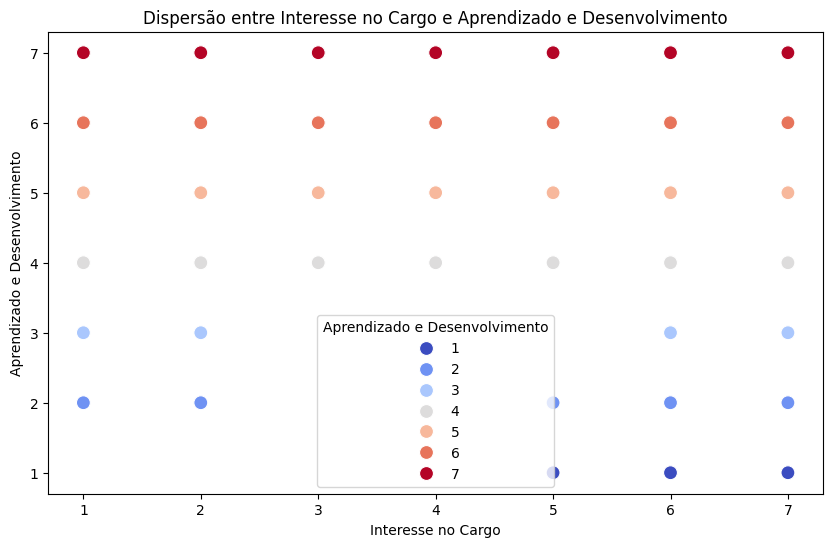

In [28]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Interesse no Cargo', y='Aprendizado e Desenvolvimento', data=data, hue='Aprendizado e Desenvolvimento', palette="coolwarm", edgecolor='w', s=100)
plt.title('Dispersão entre Interesse no Cargo e Aprendizado e Desenvolvimento')
plt.xlabel('Interesse no Cargo')
plt.ylabel('Aprendizado e Desenvolvimento')
plt.legend(title='Aprendizado e Desenvolvimento')
plt.show()

In [29]:
 # 1 se interesse ≥ 5, 0 caso contrário
data['interesse_alto'] = data['Interesse no Cargo'].apply(lambda x: 1 if x >= 5 else 0)

data['aprendizado_positivo'] = data['Aprendizado e Desenvolvimento'].apply(lambda x: 1 if x >= 5 else 0)


In [30]:
proporcao = data[data['interesse_alto'] == 1]['aprendizado_positivo'].mean()
print(f"Proporção de funcionários com interesse alto e aprendizado positivo: {proporcao:.2f}")

Proporção de funcionários com interesse alto e aprendizado positivo: 0.80


In [31]:
resultados = {
    'interesse_alto': [],
    'aprendizado_positivo': [],
    'proporcao': []
}
for interesse_alto in range(4, 8):
    for aprendizado_positivo in range(4, 8):

        proporcao = data[(data['Interesse no Cargo'] >= interesse_alto) & (data['Aprendizado e Desenvolvimento'] >= aprendizado_positivo)]['Interesse no Cargo'].count() / data[data['Interesse no Cargo'] >= interesse_alto]['Interesse no Cargo'].count()

        resultados['interesse_alto'].append(interesse_alto)
        resultados['aprendizado_positivo'].append(aprendizado_positivo)
        resultados['proporcao'].append(proporcao)

resultados_df = pd.DataFrame(resultados)

print(resultados_df.head())
print(resultados_df.info())


   interesse_alto  aprendizado_positivo  proporcao
0               4                     4   0.872146
1               4                     5   0.805936
2               4                     6   0.579909
3               4                     7   0.262557
4               5                     4   0.865060
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   interesse_alto        16 non-null     int64  
 1   aprendizado_positivo  16 non-null     int64  
 2   proporcao             16 non-null     float64
dtypes: float64(1), int64(2)
memory usage: 516.0 bytes
None


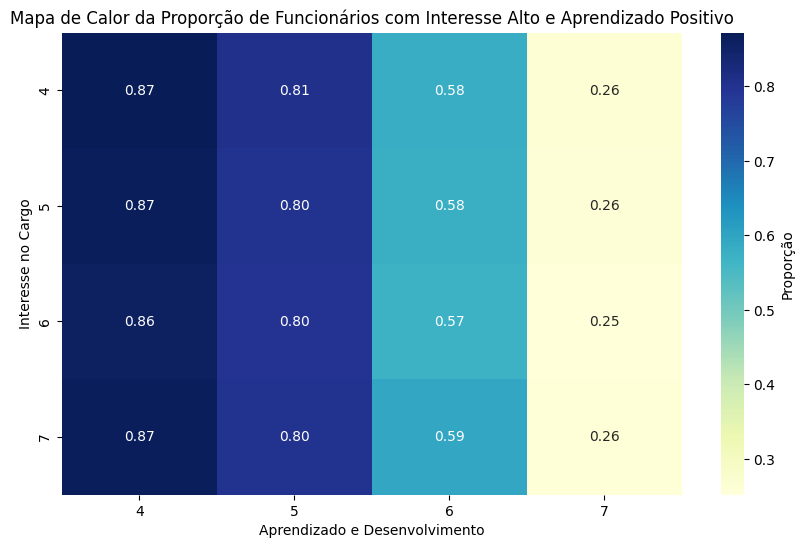

In [32]:
plt.figure(figsize=(10, 6))
heatmap_data = resultados_df.pivot(index='interesse_alto', columns='aprendizado_positivo', values='proporcao')
sns.heatmap(heatmap_data, annot=True, cmap='YlGnBu', fmt='.2f', cbar_kws={'label': 'Proporção'})
plt.title('Mapa de Calor da Proporção de Funcionários com Interesse Alto e Aprendizado Positivo')
plt.xlabel('Aprendizado e Desenvolvimento')
plt.ylabel('Interesse no Cargo')
plt.show()

A hipótese inicial de que "funcionários que demonstram interesse positivo em seu cargo também expressam sentimentos positivos em relação ao aprendizado e desenvolvimento" não se sustenta completamente com base nos resultados obtidos.

Pontos importantes:

- Correlação fraca: A correlação entre "Interesse no Cargo" e "Aprendizado e Desenvolvimento" foi de -0.07, o que indica uma relação negativa fraca. Isso sugere que, de forma geral, o interesse no cargo não está fortemente associado a sentimentos positivos sobre aprendizado e desenvolvimento.
- Proporção de 80%: Apesar da correlação fraca, a proporção de funcionários com alto interesse no cargo (nota >= 5) que também expressaram sentimentos positivos em relação ao aprendizado e desenvolvimento foi de 80%. Isso indica que a maioria dos funcionários com alto interesse no trabalho também se sente positivamente em relação ao aprendizado, mas a relação não é tão forte quanto a hipótese sugeria.
- Mapa de calor: O mapa de calor mostra que a proporção de funcionários com sentimentos positivos em relação ao aprendizado diminui à medida que o nível de interesse no cargo aumenta. Isso sugere que outros fatores, além do interesse no cargo, podem influenciar a percepção sobre o aprendizado e desenvolvimento.

Possíveis explicações:

- Fatores individuais: A motivação para o aprendizado pode ser influenciada por fatores como ambição, curiosidade e objetivos de carreira, que podem variar independentemente do interesse no cargo atual.
- Cultura da empresa: A cultura de aprendizado e desenvolvimento da empresa, a disponibilidade de oportunidades e o apoio dos gestores podem ter um impacto maior na percepção dos funcionários do que o interesse no cargo em si.
- Conteúdo do aprendizado: O tipo de aprendizado e desenvolvimento oferecido pela empresa pode não ser relevante ou interessante para todos os funcionários, mesmo aqueles com alto interesse em seus cargos.



## Conclusão Geral do Script

O script realiza uma análise exploratória de dados abrangente de um conjunto de dados de feedback de funcionários, combinando visualizações, análise de correlação e análise de sentimentos.  A EDA revela insights sobre diversas variáveis, como interesse no cargo, contribuição, feedback, interação com o gestor, aprendizado e desenvolvimento, clareza sobre as possibilidades de carreira e expectativa de permanência, segmentando os dados por departamento, cargo, gênero, localidade, tempo de empresa e geração.


Em resumo, o script oferece um ponto de partida sólido para a análise dos dados de feedback dos funcionários, revelando tendências e áreas de foco para melhorias. A aplicação de métodos mais avançados e a coleta de dados adicionais irão fortalecer as conclusões e guiar as estratégias de gestão de pessoas de forma mais eficaz.